In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing required libraries for that manipulation and analysis

In [76]:
# Loading and inspecting  datasets

Basics = pd.read_csv("/content/Title.basics1.csv")
Ratings = pd.read_csv("/content/Title.ratings .csv")
Bom = pd.read_csv("/content/bom.movie_gross (1).csv")

In [77]:
#Dispalying the first 5 rows of each dataset

Basics.head(5)


,tconst,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [78]:
Ratings.head(5)

,tconst,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [79]:
Bom.head(5)

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [80]:
#Checking summary statistics

Basics.describe()

,start_year,runtime_minutes
count,146144.000000,114405.000000
mean,2014.621798,86.187247
std,2.733583,166.360590
min,2010.000000,1.000000
25%,2012.000000,70.000000
50%,2015.000000,87.000000
75%,2017.000000,99.000000
max,2115.000000,51420.000000


In [81]:
Ratings.describe()

,averagerating,numvotes
count,73856.000000,7.385600e+04
mean,6.332729,3.523662e+03
std,1.474978,3.029402e+04
min,1.000000,5.000000e+00
25%,5.500000,1.400000e+01
50%,6.500000,4.900000e+01
75%,7.400000,2.820000e+02
max,10.000000,1.841066e+06


In [82]:
Bom.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [83]:
Basics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           146144 non-null  object 
 1   primary_title    146143 non-null  object 
 2   original_title   146122 non-null  object 
 3   start_year       146144 non-null  int64  
 4   runtime_minutes  114405 non-null  float64
 5   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.7+ MB


In [84]:
Ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tconst         73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [85]:
Bom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


Checking missing values

In [86]:
Basics.isnull().sum()

,0
tconst,0
primary_title,1
original_title,22
start_year,0
runtime_minutes,31739
genres,5408


In the above dtaset Basics we have 1 missing entryin th column -primary title.
22 missing entries in column -original title.
31739 missing values in column - runtime minutes, while genre has 5408 missing values.  
The rest of the cpumns have all entries

In [87]:
Ratings.isnull().sum()

,0
tconst,0
averagerating,0
numvotes,0


This dataset has no missing values

In [88]:
Bom.isnull().sum()

,0
title,0
studio,5
domestic_gross,28
foreign_gross,1350
year,0


Studio column has 5 missing entries. Domestic gross has 28 missing values. foreign gross has 1350 missing values. The rest have complete entries.

**Cleaning Basics data set**

In [89]:
#Handling runtime_minutes missing values by using median
Runtime_missing = Basics['runtime_minutes'].median()
Basics['runtime_minutes'].fillna(Runtime_missing)




,runtime_minutes
0,175.0
1,114.0
2,122.0
3,87.0
4,80.0
...,...
146139,123.0
146140,87.0
146141,87.0
146142,116.0


In [90]:
#Handling missing genre values with unknown
Basics['genres'].fillna('unknown')

,genres
0,"Action,Crime,Drama"
1,"Biography,Drama"
2,Drama
3,"Comedy,Drama"
4,"Comedy,Drama,Fantasy"
...,...
146139,Drama
146140,Documentary
146141,Comedy
146142,unknown


In [91]:
Basics['primary_title'].fillna('unknown')

,primary_title
0,Sunghursh
1,One Day Before the Rainy Season
2,The Other Side of the Wind
3,Sabse Bada Sukh
4,The Wandering Soap Opera
...,...
146139,Kuambil Lagi Hatiku
146140,Rodolpho Teóphilo - O Legado de um Pioneiro
146141,Dankyavar Danka
146142,6 Gunn


In [92]:
# Drop rows with missing original title
Basics_cleaned = Basics.dropna(subset=['original_title'])

In [93]:
Basics_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146122 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           146122 non-null  object 
 1   primary_title    146122 non-null  object 
 2   original_title   146122 non-null  object 
 3   start_year       146122 non-null  int64  
 4   runtime_minutes  114401 non-null  float64
 5   genres           140733 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 7.8+ MB


Cleaning BOM dataset

In [94]:
# filling missing value in studio
Bom['studio'].fillna('unknown')

,studio
0,BV
1,BV
2,WB
3,WB
4,P/DW
...,...
3382,Magn.
3383,FM
3384,Sony
3385,Synergetic


In [95]:
#filling in foreign gross
Bom['foreign_gross'] = pd.to_numeric(Bom['foreign_gross'],errors='coerce')

In [96]:
# Handling domestivc gross
Bom_cleaned = Bom.dropna(subset=['domestic_gross'])

In [97]:
Bom_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3359 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3359 non-null   object 
 1   studio          3356 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2004 non-null   float64
 4   year            3359 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 157.5+ KB


Merging the Basics and Ratings data sets since they share a common colunm that is the tconst

In [98]:
# merging the two tables that is Basics_cleaned and Ratings
Basics_Ratings = pd.merge(Basics_cleaned, Ratings, on = 'tconst')

In [99]:
Basics_Ratings.head(10)

,tconst,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119
5,tt0112502,Bigfoot,Bigfoot,2017,NaN,"Horror,Thriller",4.1,32
6,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy",8.1,263
7,tt0146592,Pál Adrienn,Pál Adrienn,2010,136.0,Drama,6.8,451
8,tt0154039,So Much for Justice!,Oda az igazság,2010,100.0,History,4.6,64
9,tt0159369,Cooper and Hemingway: The True Gen,Cooper and Hemingway: The True Gen,2013,180.0,Documentary,7.6,53


In [100]:
Basics_Ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   original_title   73856 non-null  object 
 3   start_year       73856 non-null  int64  
 4   runtime_minutes  66236 non-null  float64
 5   genres           73052 non-null  object 
 6   averagerating    73856 non-null  float64
 7   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


###VISUALIZATIONS

***Total Gross revenue by year***

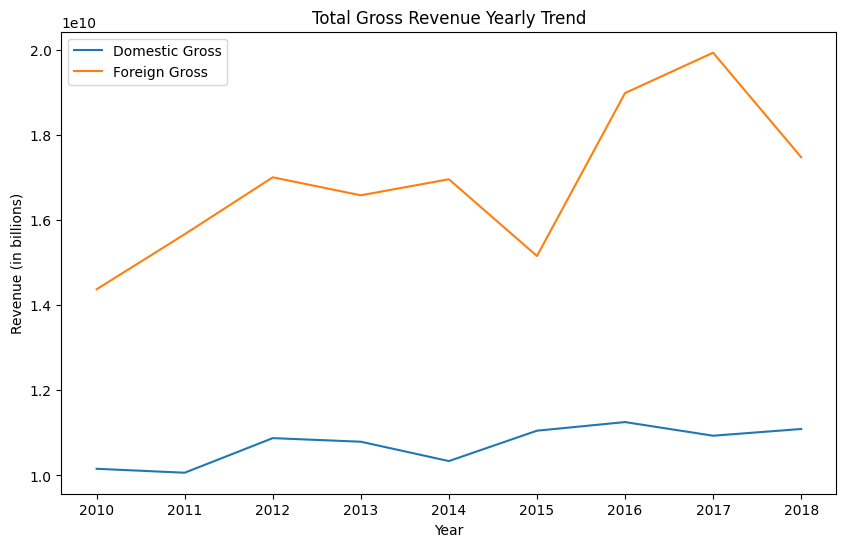

In [101]:
# Total domestic and foreign gross revenue by year
Total_gross_by_year = Bom_cleaned.groupby('year')[['domestic_gross', 'foreign_gross']].sum().reset_index()


#plot total gross revenue by year
plt.figure(figsize=(10, 6))
sns.lineplot(data = Total_gross_by_year, x='year', y='domestic_gross', label='Domestic Gross')
sns.lineplot(data = Total_gross_by_year, x='year', y='foreign_gross', label='Foreign Gross')
plt.title('Total Gross Revenue Yearly Trend')
plt.xlabel('Year')
plt.ylabel('Revenue (in billions)')
plt.legend()
plt.show()

**The line graph above shows that over the years, foreign revenues from movie production have surpassed domestic revenues.**

***Top 10 movies***

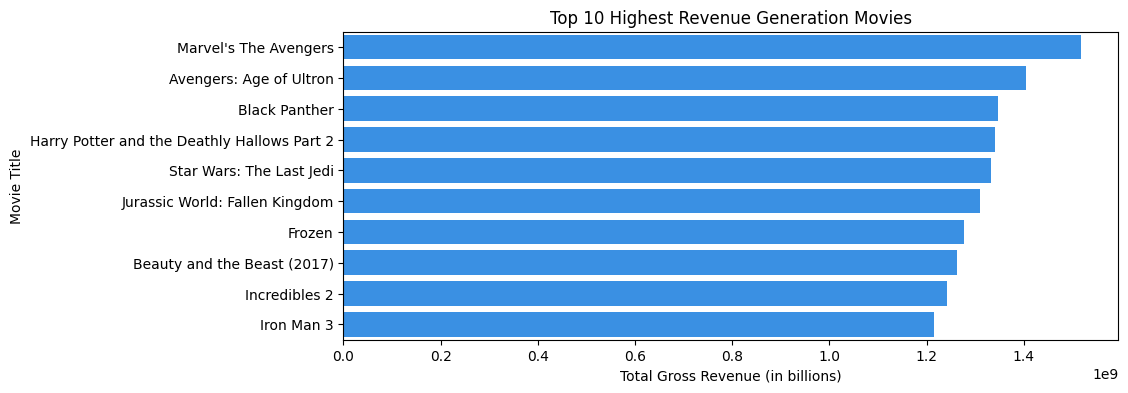

In [102]:
# Make a copy of the cleaned Bom data set, this is to help up introduce .loc without inferearing with the original cleaned data.
Bom_cleaned = Bom_cleaned.copy()

# Calculating total gross revenue
Bom_cleaned.loc[:, 'Total_gross'] = Bom_cleaned['domestic_gross'] + Bom_cleaned['foreign_gross']

# Getting the top 10 highest revenue generating movies
top_10_grossing_movies = Bom_cleaned.sort_values(by='Total_gross', ascending=False).head(10)

# Plot top 10 highest revenue generating movies
plt.figure(figsize=(10, 4))
sns.barplot(data=top_10_grossing_movies, x='Total_gross', y='title', color='dodgerblue', alpha=1.0)
plt.title('Top 10 Highest Revenue Generation Movies')
plt.xlabel('Total Gross Revenue (in billions)')
plt.ylabel('Movie Title')
plt.show()

**From the above bar graph, Marvel's The Avengers stands out as the highest revenue-generating movie in both domestic and international markets.**

***Distribution of revenue***

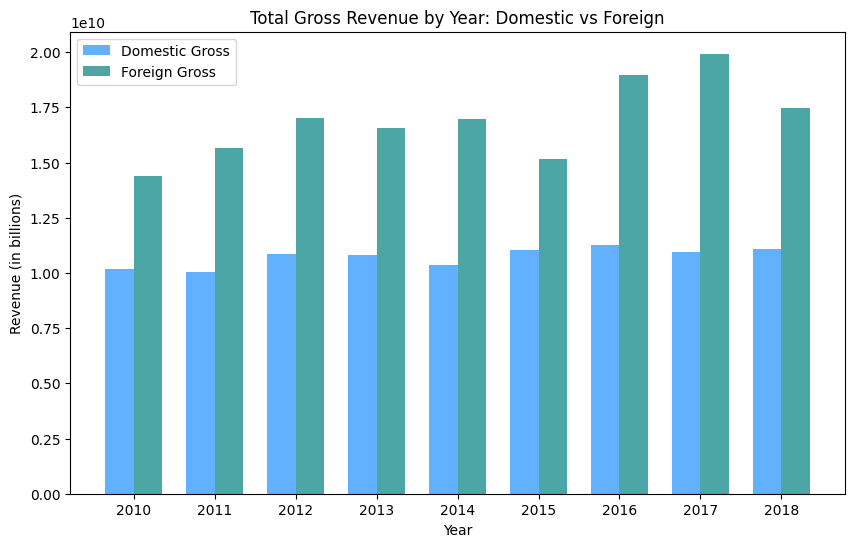

In [103]:
#Plot distribution of domestic and foreign gross revenue

bins = np.arange(0, Bom_cleaned[['domestic_gross', 'foreign_gross']].max().max() + 50e6, 50e6)

# Count how many movies fall in each bin

plt.figure(figsize=(10, 6))

x_pos = np.arange(len(Total_gross_by_year))
width = 0.35

plt.bar(x_pos - width/2, Total_gross_by_year['domestic_gross'], width, label='Domestic Gross', color='dodgerblue', alpha=0.7)
plt.bar(x_pos + width/2, Total_gross_by_year['foreign_gross'], width, label='Foreign Gross', color='teal', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Revenue (in billions)')
plt.title('Total Gross Revenue by Year: Domestic vs Foreign')
plt.xticks(x_pos, Total_gross_by_year['year'])
plt.legend()
plt.show()

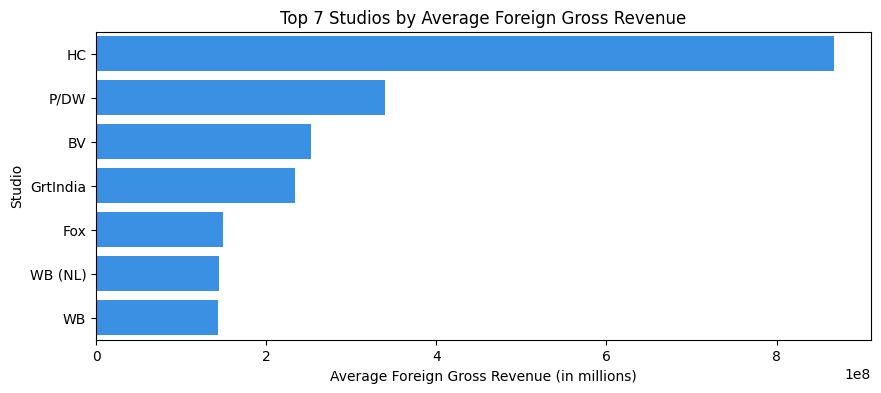

In [104]:
#Checking for top 7 best Foreign revenue generating studios
# Group by studio and calculate average domestic and foreign gross revenue
average_gross_by_studio = Bom_cleaned.groupby('studio')[['domestic_gross', 'foreign_gross']].mean().reset_index()

# Top 7 Studios by Foreign Gross
top_7_foreign_gross_studios = average_gross_by_studio.sort_values(by='foreign_gross', ascending=False).head(7)

# Plot top 7 studios by foreign gross
plt.figure(figsize=(10, 4))
sns.barplot(data=top_7_foreign_gross_studios, x='foreign_gross', y='studio', color='dodgerblue')
plt.title('Top 7 Studios by Average Foreign Gross Revenue')
plt.xlabel('Average Foreign Gross Revenue (in millions)')
plt.ylabel('Studio')
plt.show()

**HC Studios is leading as the top revenue-generating studio in the international market, generating the most foreign revenue.**

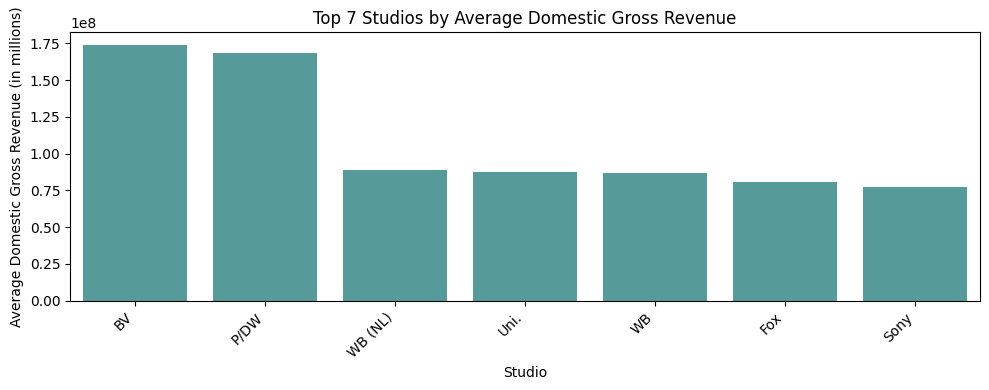

In [105]:
#top 7 studios by average domestic revenue
top_7_domestic_gross_studios = average_gross_by_studio.sort_values(by='domestic_gross', ascending=False).head(7)
plt.figure(figsize=(10, 4))
sns.barplot(
    data=top_7_domestic_gross_studios,
    x='studio',
    y='domestic_gross',
    color='teal', alpha=0.7
)

plt.title('Top 7 Studios by Average Domestic Gross Revenue')
plt.xlabel('Studio')
plt.ylabel('Average Domestic Gross Revenue (in millions)')

# makes studio names readable if they're long
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**From the graph above, BV studio leads as the most domestic revenue geneating studio.**

**Distribution of movies runtime**

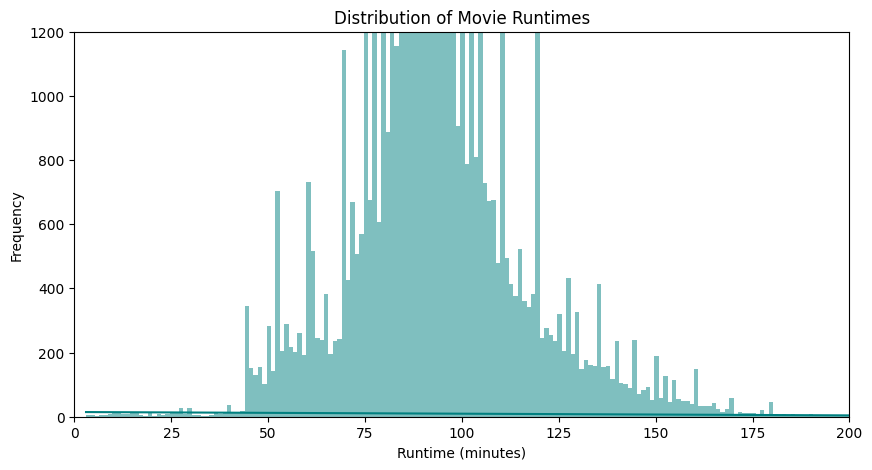

In [106]:
# Ploting distribution of movie runtimes
plt.figure(figsize=(10, 5))
sns.histplot(Basics_Ratings['runtime_minutes'], kde=True, color='teal')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.ylim(0, 1200)  # Set y-axis limits to be between 0 and 1200
plt.xlim(0,200) #set the x- axis liiits to be betwee 0 and 200
plt.show()

**From the graph above, it is clear that the majority of movie runtimes fall between 70 and 120 minutes.**

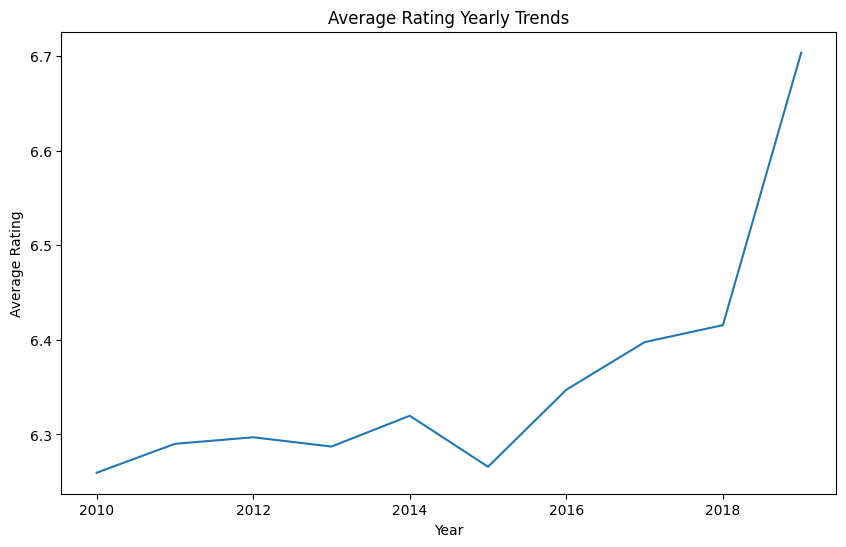

In [107]:

# Grouping by start year and calculate average rating
average_rating_by_year = Basics_Ratings.groupby('start_year')['averagerating'].mean().reset_index()

# Plotting average rating over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_rating_by_year, x='start_year', y='averagerating')
plt.title('Average Rating Yearly Trends')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

**The above graph shows that the average rating for movies has been on the rise over the years.**

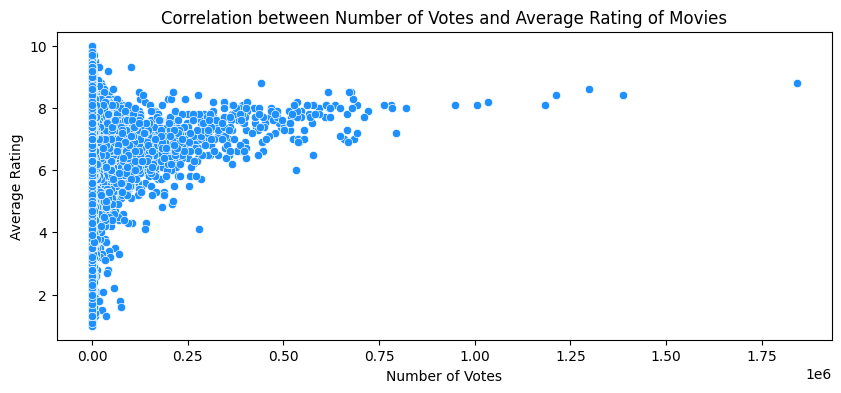

In [108]:
# Ploting correlation between number of votes and average rating
plt.figure(figsize=(10, 4))
sns.scatterplot(data=Ratings, x='numvotes', y='averagerating', color='dodgerblue')
plt.title('Correlation between Number of Votes and Average Rating of Movies')
plt.xlabel('Number of Votes')
plt.ylabel('Average Rating')
plt.show()

**From the scatterplot above, we can affirm that movies with the highest rating, received relatively higher number of votes.**

In [109]:
#Listing the top 15 genres by rating
top_15_by_rating = (
    Basics_Ratings
    .assign(genres=Basics_Ratings['genres'].str.split(','))
    .explode('genres')
    .groupby('genres')['averagerating']
    .mean()
    .sort_values(ascending=False)
    .head(15))
top_15_by_rating.head(15)

,averagerating
genres,
Short,8.800000
Documentary,7.332090
Game-Show,7.300000
News,7.271330
Biography,7.162274
Music,7.091972
History,7.040956
Sport,6.961493
War,6.584291


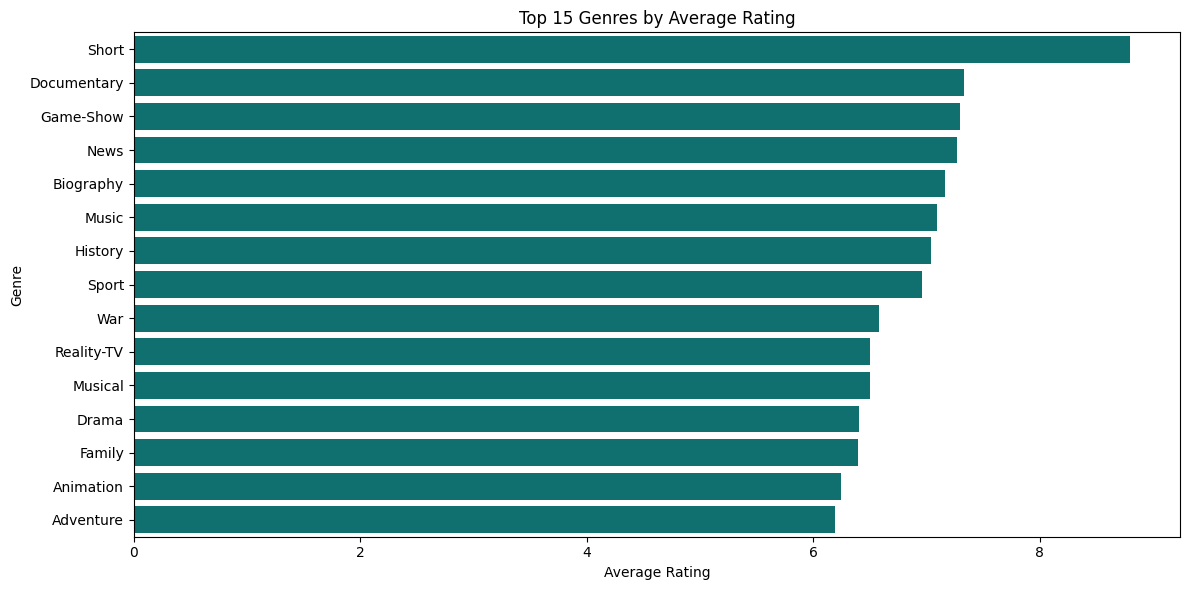

In [110]:
top_15_rating_df = (
    Basics_Ratings
    .assign(genres=Basics_Ratings['genres'].str.split(','))
    .explode('genres')
    .groupby('genres')['averagerating']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_15_rating_df,
    x='averagerating',
    y='genres', color='teal'
)

plt.title('Top 15 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The graph shows the best top 15 movie genres by ratings

##**Average rating trends by year**

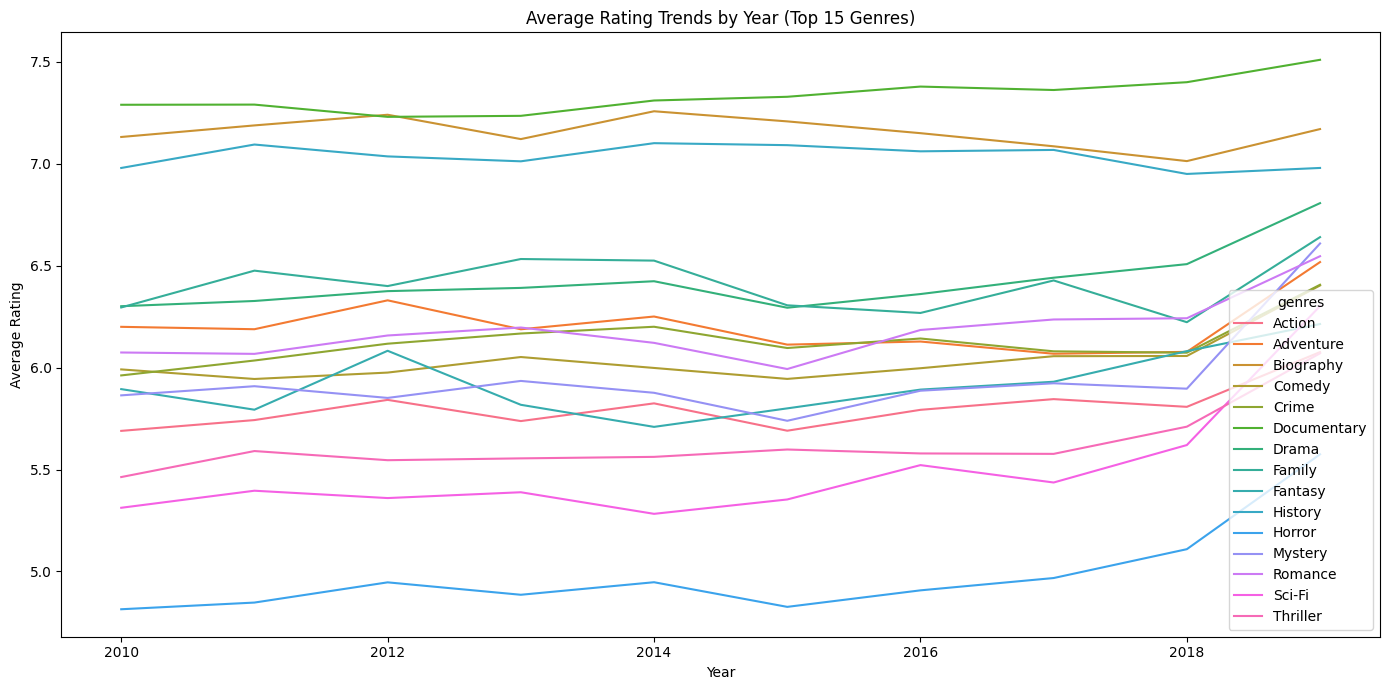

In [113]:
#Avereage rating trends by year
genre_year_avg = (
    df_top.groupby(['start_year', 'genres'])['averagerating']
    .mean()
    .reset_index()
)
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=genre_year_avg,
    x='start_year',
    y='averagerating',
    hue='genres',
    legend=True  # remove legend
)

# Add text labels at the end of each line
for genre in genre_year_avg['genres'].unique():
    genre_data = genre_year_avg[genre_year_avg['genres'] == genre].sort_values('start_year')
    last_row = genre_data.iloc[-1]
plt.title('Average Rating Trends by Year (Top 15 Genres)')
plt.xlabel('Year')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

**Documentary and History sit at the top almost the whole decade, generally around the low-to-mid 7s, and they finish near the top by 2019. In plain terms, these genres tend to receive stronger average ratings than most others**

/tmp/ipython-input-752671240.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['runtime_bin', 'genres'])


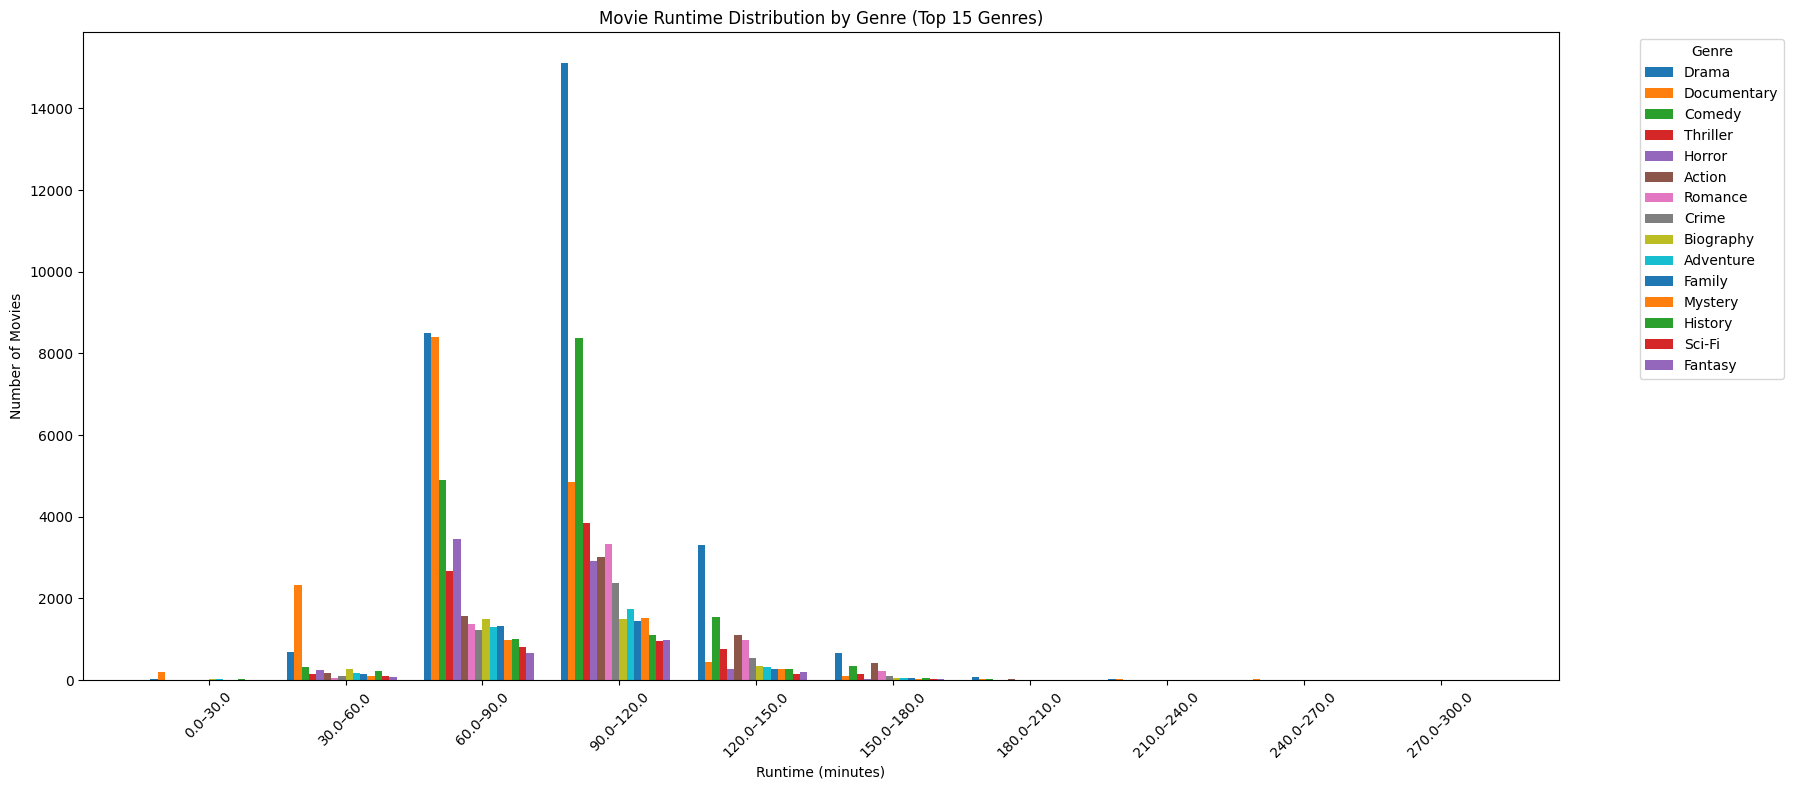

In [112]:
# Copy dataset
df = Basics_Ratings.copy()

# Clean data
df = df.dropna(subset=['runtime_minutes', 'genres'])

# Split and explode genres
df['genres'] = df['genres'].str.split(',')
df = df.explode('genres')

# Select top 15 genres
top_15_genres = df['genres'].value_counts().head(15).index
df_top = df[df['genres'].isin(top_15_genres)]

# Optional: limit extreme runtimes for clarity
df_top = df_top[df_top['runtime_minutes'] <= 300]

# Create runtime bins (30 minutes)
bins = np.arange(0, df_top['runtime_minutes'].max() + 30, 30)
bin_labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# Assign each movie to a runtime bin
df_top['runtime_bin'] = pd.cut(
    df_top['runtime_minutes'],
    bins=bins,
    labels=bin_labels,
    right=False
)

# Count movies per (runtime bin × genre)
counts_df = (
    df_top
    .groupby(['runtime_bin', 'genres'])
    .size()
    .unstack(fill_value=0)
)

# Keep only top 15 genres and correct order
counts_df = counts_df[top_15_genres]

# SIDE-BY-SIDE BAR PLOT

plt.figure(figsize=(18, 8))

x = np.arange(len(counts_df))               # runtime bins
bar_width = 0.8 / len(top_15_genres)        # width per genre bar

for i, genre in enumerate(top_15_genres):
    plt.bar(
        x + i * bar_width,
        counts_df[genre],
        width=bar_width,
        label=genre
    )

plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.title('Movie Runtime Distribution by Genre (Top 15 Genres)')
plt.xticks(
    x + bar_width * len(top_15_genres) / 2,
    counts_df.index,
    rotation=45
)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**From the above stacked bar chart it shows that most movies are between 60 to 120 minutes, with very few movies beyond 150 minutes.**

###**FINDINGS AND RECOMMENDATIONS**

REVENUE;
foreign reveunue has surpassed domestic revenue over the yreas
Domestic revenue has been faily stable while foreign revenue took a deep in 2025 , spiked in 2026 and is now deeping again in 2018

Reccomendation;
 (1)Strengthen Domestic Revenue as a Safety Net by Streaming and digital releases, Targeted domestic marketing and also partnership with other movie stakeholders.
 (2) use predictive analysis to understand future trends for foreign revenue to come up with risk management plan.
 (3)Optimize Release & Distribution Strategy by tailoring content and release timing to regional preferences.


STDIOS;
BV, P/DW, WBare the top 3 studios in domestic gross revenue. HC, P/DW, BV  are the top 3 studions in foreign gross revenue.
Recommendation;
Leverage top domestic performers (BV, P/DW, WB) for stable home-market revenue through sequels, franchises, and targeted marketing.

Capitalize on strong foreign performers (HC, P/DW, BV) by expanding international distribution, partnerships, and tailored content strategies.

Align global and domestic strategies by using studios that perform well in both markets (P/DW, BV) to reduce risk and maximize cross-market revenue potential.
Prioritize and support P/DW projects, leveraging its strong performance in both domestic and international markets to maximize overall gross revenue and reduce market risk.

RATINGS;
The average ratings of the mobvies has been on the rising over the years with a huge spike/ rise in 2018.

There is a positive correlation bettween number of votes and average rating of movies.

Invest in high-visibility projects. movies likely to attract large audiences (more votes) are more likely to achieve higher ratings.

Encourage audience engagement and voting. promote platforms or campaigns that boost viewer participation to improve perceived movie quality.

Analyze 2018 spike drivers. identify what caused the sudden rise (genre, marketing, cast, release strategy) and replicate successful strategies in future releases.

GENRES;
Top-rated genres: Short, Documentary, Game Show, News, Biography.
Least preferred genres: Adventure, Animation, Family.
While other movie genres dipped in 2015, the top three maintaned a lightly higher rise

Recommendations

Focus on high-rated genres. prioritize producing or promoting content in Short, Documentary, Game Show, News, and Biography to maximize critical acclaim and audience satisfaction.

Reevaluate low-rated genres analyze why Adventure, Animation, and Family are underperforming (story quality, marketing, or audience mismatch) before investing heavily.

Balance portfolio strategically. maintain some presence in popular genres for box office or streaming appeal, but align most resources toward high-rated genres to build reputation and ratin

